In [1]:
# Standard library
import os  

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb  

# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


In [2]:
example_session_ids =  [
                        '668755_2023-08-31', '674562_2023-10-03', '759434_2025-02-04', '713655_2024-08-09', '664851_2023-11-13', '686740_2023-10-24' \
                        '712815_2024-05-22', '743199_2024-12-05', '686176_2023-12-04', '702131_2024-02-26', '746439_2025-01-31', '667252_2023-09-26',\
                        ]

session_id = example_session_ids[0]

In [3]:
# HMM-related imports from JAX, Dynamax, and TensorFlow Probability
from functools import partial
import jax.numpy as jnp
import jax.random as jr
from dynamax.hidden_markov_model import GaussianHMM
from dynamax.utils.utils import find_permutation
from dynamax.utils.plotting import CMAP, COLORS, white_to_color_cmap

In [ ]:
# Instantiate an HMM object for fitting
true_num_states = 4
observations_dim = 2
hmm = GaussianHMM(true_num_states, observations_dim)

In [5]:

# Make an HMM
true_num_states = 4
observations_dim = 2
hmm = GaussianHMM(true_num_states, observations_dim)

# 1. Set the initial state distribution
initial_probs = jnp.ones(true_num_states) / true_num_states

# 2. Make a transition matrix
transition_matrix = 0.80 * jnp.eye(true_num_states) \
    + 0.15 * jnp.roll(jnp.eye(true_num_states), 1, axis=1) \
    + 0.05 / true_num_states

# 3. Set the the emission probabilities - mean and covariances
emission_means = jnp.column_stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, true_num_states + 1))[:-1],
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, true_num_states + 1))[:-1],
    jnp.zeros((true_num_states, observations_dim - 2)),
    ])
emission_covs = jnp.tile(0.25**2 * jnp.eye(observations_dim), (true_num_states, 1, 1))

# Construct the HMM - this will be our ground truth 
true_params, _ = hmm.initialize(initial_probs=initial_probs,
                                transition_matrix=transition_matrix,
                                emission_means=emission_means,
                                emission_covariances=emission_covs)

In [6]:
key = jr.PRNGKey(0)

In [7]:
num_timesteps = 100
true_states, true_observations = hmm.sample(key=key, params=true_params, num_timesteps=num_timesteps)
true_states

Array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3, 3, 3, 3, 3, 3, 0,
       0, 1, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2], dtype=int32)

In [8]:
# Helper functions for plotting
def plot_gaussian_hmm(hmm, params, emissions, states,  title="Emission Distributions", alpha=0.25):
    """
    Visualize a 2D Gaussian HMM by plotting emission distributions and observed data trajectories.
    
    Creates a comprehensive plot showing:
    - Contour plots of each state's Gaussian emission distribution
    - Observed data points colored by their true hidden state
    - Connected trajectory path showing temporal sequence
    
    Parameters
    ----------
    hmm : GaussianHMM
        A fitted Gaussian Hidden Markov Model from dynamax with 2D emissions.
    params : dict or NamedTuple
        HMM parameters containing emission means, covariances, and transition matrices.
        Typically obtained from hmm.initialize() or hmm.fit().
    emissions : array_like, shape (T, 2)
        Sequence of 2D observations/emissions over time T.
    states : array_like, shape (T,)
        True hidden state sequence corresponding to each emission.
        Values should be integers in range [0, hmm.num_states).
    title : str, optional
        Plot title. Default is "Emission Distributions".
    alpha : float, optional
        Transparency level for data points and trajectory line (0-1). Default is 0.25.
        
    Returns
    -------
    None
        Displays the plot using matplotlib.
    """
    lim = 1.1 * abs(emissions).max()
    XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
    grid = jnp.column_stack((XX.ravel(), YY.ravel()))

    plt.figure()
    for k in range(hmm.num_states):
        lls = hmm.emission_distribution(params, k).log_prob(grid)
        plt.contour(XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k]))
        plt.plot(emissions[states == k, 0], emissions[states == k, 1], "o", mfc=COLORS[k], mec="none", ms=5, alpha=alpha)

    plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
    plt.xlabel("$y_1$")
    plt.ylabel("$y_2$")
    plt.title(title)
    plt.gca().set_aspect(1.0)
    plt.tight_layout()

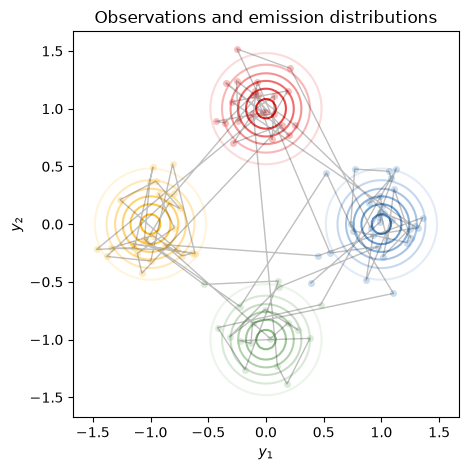

In [9]:
# Visualize emission distributions, observation sequence, and true_states 
plot_gaussian_hmm(hmm, true_params, true_observations, true_states, 
                  title="Observations and emission distributions")